In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT
from model import SSLModel
from data_split import create_train_val_split
from extract_XLSR_feature import extract_features_from_csv
from visualization import plot_training_curves, plot_dataset_comparison
from dataset import create_dataloaders
from train import train
import numpy as np

/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "Pitt"
data_version = "raw"

In [3]:
# RAW_AUDIO_DIR = PROJECT_ROOT / f"data/denoised/{DATASET_NAME}"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/{data_version}/{DATASET_NAME}"

XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_xlsr_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using cuda


## Step 1: Train/Validation Set Split

In [5]:
# Define CSV paths
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"

# Create CSV files if they don't exist
if not TRAIN_CSV.exists() or not VAL_CSV.exists():
    TRAIN_CSV, VAL_CSV = create_train_val_split(
        raw_audio_dir=RAW_AUDIO_DIR,
        dataset_name=DATASET_NAME,
        feature_dir_name=FEATURE_DIR_NAME,
        xlsr=True
    )


## Step 2: Extract XLSR Features

In [6]:
ssl_model = SSLModel(device, freeze_xlsr=True)

extract_features_from_csv(
    csv_path=TRAIN_CSV,
    split_name="Train Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)

extract_features_from_csv(
    csv_path=VAL_CSV,
    split_name="Val Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


XLSR: Loading base model structure


/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Using original pretrained model

============= Extracting XLSR features for Train Set =============
440 Audio Files


Extracting Train Set: 100%|██████████| 440/440 [00:00<00:00, 49244.68it/s]


Successfully extracted: 0
Already exists (skipped): 440
Errors: 0
Total: 440

============= Extracting XLSR features for Val Set =============
111 Audio Files


Extracting Val Set: 100%|██████████| 111/111 [00:00<00:00, 40590.04it/s]

Successfully extracted: 0
Already exists (skipped): 111
Errors: 0
Total: 111


(0, 111, 111)

## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=True)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 111 samples
Control: 49, Dementia: 62




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21


Seed 21:
Val Acc=66.67%, F1=0.7259, Val Loss=0.7829
Control Acc=51.02%, Dementia Acc=79.03%
Early stop at: epoch 20 (best epoch: 10)


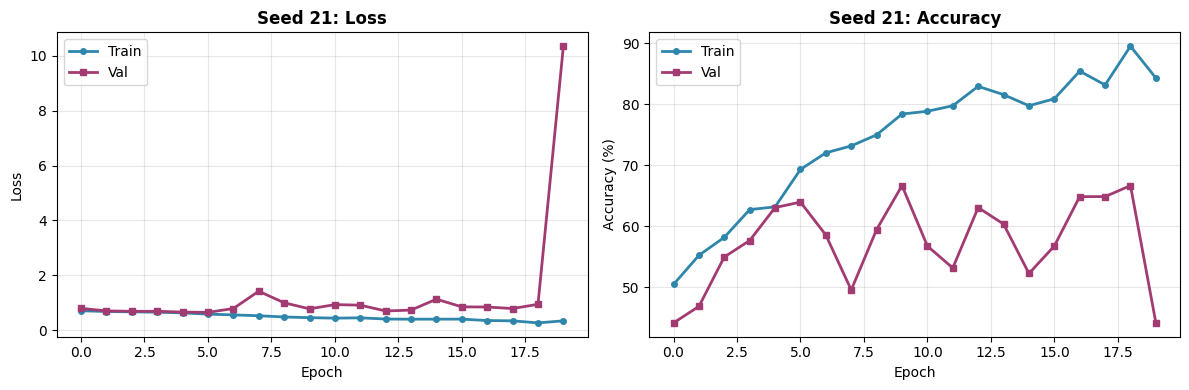

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42:
Val Acc=68.47%, F1=0.7328, Val Loss=0.8783
Control Acc=57.14%, Dementia Acc=77.42%
Early stop at: epoch 27 (best epoch: 17)


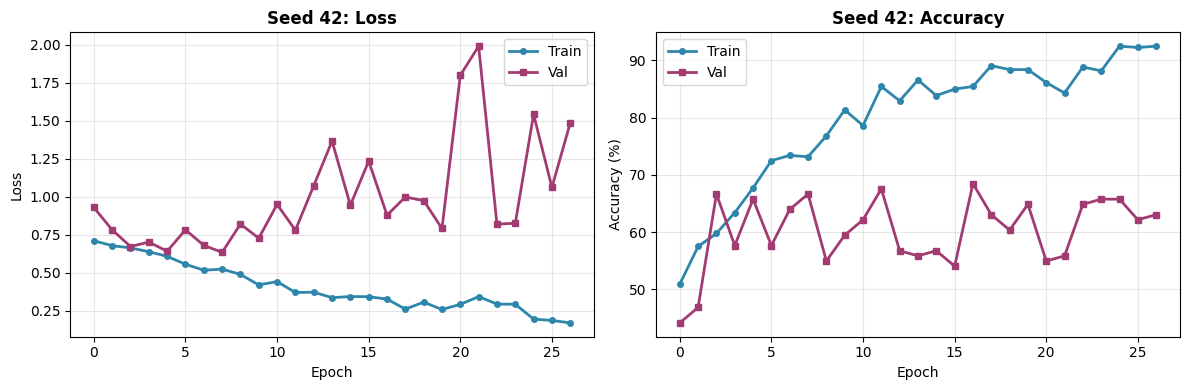

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84:
Val Acc=69.37%, F1=0.7344, Val Loss=1.0268
Control Acc=61.22%, Dementia Acc=75.81%
Early stop at: epoch 35 (best epoch: 25)


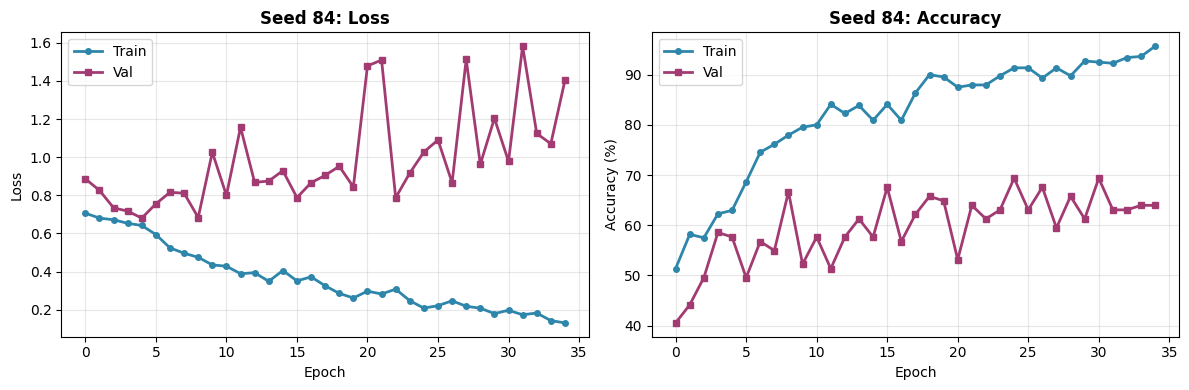

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168:
Val Acc=66.67%, F1=0.6992, Val Loss=0.8694
Control Acc=63.27%, Dementia Acc=69.35%
Early stop at: epoch 25 (best epoch: 15)


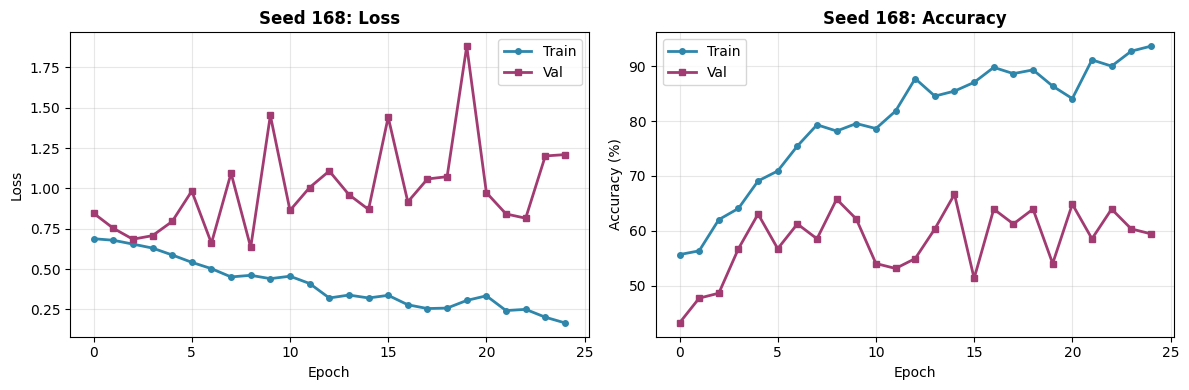

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336:
Val Acc=67.57%, F1=0.7313, Val Loss=0.6404
Control Acc=53.06%, Dementia Acc=79.03%
Early stop at: epoch 17 (best epoch: 7)


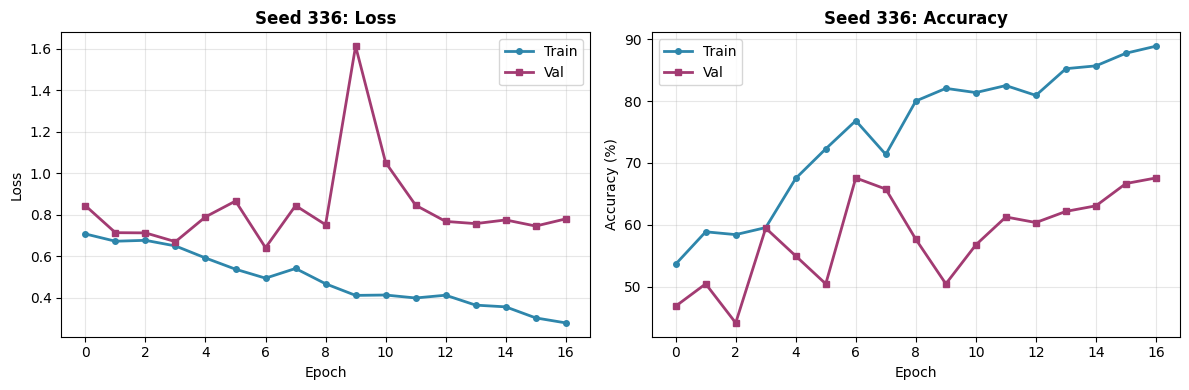

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")


Mean Validation Accuracy: 67.75% ± 1.17%
Mean Validation Loss: 0.8396 ± 0.1417
Mean Control Accuracy: 57.14% ± 5.20%
Mean Dementia Accuracy: 76.13% ± 4.02%
Mean F1 Score: 0.7247 ± 0.0146

Detailed Results:
Seed 21: Acc=66.67%, Loss=0.7829, Control Acc=51.02%, Dementia Acc=79.03%, F1=0.7259
Seed 42: Acc=68.47%, Loss=0.8783, Control Acc=57.14%, Dementia Acc=77.42%, F1=0.7328
Seed 84: Acc=69.37%, Loss=1.0268, Control Acc=61.22%, Dementia Acc=75.81%, F1=0.7344
Seed 168: Acc=66.67%, Loss=0.8694, Control Acc=63.27%, Dementia Acc=69.35%, F1=0.6992
Seed 336: Acc=67.57%, Loss=0.6404, Control Acc=53.06%, Dementia Acc=79.03%, F1=0.7313


## Step 7: Test Best Model on Multiple Datasets


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
else:
    best_idx = max_acc_indices[0]

# Get best model info
BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"

In [16]:
# Load the best model
from model import AD_XLSR_Model
from test import test_on_dataset, test_on_dataset_with_val_csv

# Create model with XLSR configuration
test_model = AD_XLSR_Model()

# Load checkpoint (state_dict was saved directly)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
test_model.load_state_dict(checkpoint)
test_model = test_model.to(device)
test_model.eval()

# Define reference validation CSV for consistent testing across datasets
# Use Pitt-Best validation set as the reference for all three datasets
REFERENCE_VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
print(f"Reference VAL_CSV: {REFERENCE_VAL_CSV}")

Reference VAL_CSV: /root/autodl-tmp/Few-Shot_is_all_you_need/ad_detection/data/processed/Pitt-xlsr-val.csv


In [18]:

# Get session_id sets
pitt_sessions = set(pitt_val_df['session_id'])
pitt_best_sessions = set(pitt_best_val_df['session_id'])
pitt_residual_sessions = set(pitt_residual_val_df['session_id'])

# Check consistency
print("=== Validation Set Consistency Check ===")
print(f"Pitt sessions: {len(pitt_sessions)}")
print(f"Pitt-Best sessions: {len(pitt_best_sessions)}")
print(f"Pitt-residual-Best sessions: {len(pitt_residual_sessions)}")
print()

if pitt_sessions == pitt_best_sessions == pitt_residual_sessions:
    print("✓ All three datasets use the SAME validation set!")
    print(f"  Total validation samples: {len(pitt_sessions)}")
    
    # Show sample session_ids
    sample_ids = sorted(list(pitt_sessions))[:5]
    print(f"  Sample session_ids: {sample_ids}")
    
    # Verify labels are also consistent
    pitt_val_df_sorted = pitt_val_df.sort_values('session_id')
    pitt_best_val_df_sorted = pitt_best_val_df.sort_values('session_id')
    pitt_residual_val_df_sorted = pitt_residual_val_df.sort_values('session_id')
    
    labels_match = (
        list(pitt_val_df_sorted['ad']) == list(pitt_best_val_df_sorted['ad']) and
        list(pitt_best_val_df_sorted['ad']) == list(pitt_residual_val_df_sorted['ad'])
    )
    
    if labels_match:
        print("✓ Labels (AD status) are also consistent across datasets!")
    else:
        print("⚠ WARNING: Labels differ across datasets!")
else:
    print("✗ ERROR: Datasets use DIFFERENT validation sets!")
    print(f"  Pitt only: {pitt_sessions - pitt_best_sessions - pitt_residual_sessions}")
    print(f"  Pitt-Best only: {pitt_best_sessions - pitt_sessions - pitt_residual_sessions}")
    print(f"  Pitt-residual-Best only: {pitt_residual_sessions - pitt_sessions - pitt_best_sessions}")

=== Validation Set Consistency Check ===
Pitt sessions: 0
Pitt-Best sessions: 0
Pitt-residual-Best sessions: 111

✗ ERROR: Datasets use DIFFERENT validation sets!
  Pitt only: set()
  Pitt-Best only: set()
  Pitt-residual-Best only: {'337-0', '476-0', '143-3', '022-0', '034-1', '276-0', '208-2', '492-0', '050-0', '342-1', '242-0', '354-0', '318-1', '013-0', '340-0', '209-3', '137-3', '033-1', '073-3', '093-1', '631-0', '368-0', '035-0', '125-0', '702-0', '096-1', '232-1', '166-0', '289-2', '660-0', '057-2', '172-0', '016-1', '033-4', '030-1', '248-2', '227-0', '691-0', '205-1', '223-0', '221-2', '022-1', '086-2', '062-3', '175-2', '071-4', '013-2', '248-1', '002-1', '598-0', '360-0', '001-2', '318-2', '094-3', '256-2', '158-0', '006-4', '127-0', '511-0', '052-0', '674-0', '226-0', '049-1', '071-3', '635-0', '349-1', '688-0', '497-0', '323-0', '130-3', '010-0', '350-0', '280-1', '663-0', '212-0', '114-2', '243-1', '458-0', '058-0', '355-1', '157-2', '042-4', '171-1', '164-1', '508-1', '

In [19]:
# Test on ADReSS dataset
adress_results = test_on_dataset(
    dataset_name="ADReSS",
    model=test_model,
    device=device,
    ssl_model=ssl_model,
    raw_audio_dir="data/raw/ADReSS"
)


Testing on ADReSS Dataset


============= Extracting XLSR features for ADReSS Test Set =============
156 Audio Files


Extracting ADReSS Test Set: 100%|██████████| 156/156 [00:00<00:00, 44165.47it/s]

Successfully extracted: 0
Already exists (skipped): 156
Errors: 0
Total: 156


Loading completed: 156 samples
Control: 78, Dementia: 78




Testing on ADReSS: 100%|██████████| 5/5 [00:00<00:00, 13.79it/s]


Overall Accuracy: 88.46%, F1 Score: 0.8902
Control Accuracy: 83.33%, Dementia Accuracy: 93.59%


In [20]:
# Test on Lu dataset
lu_results = test_on_dataset(
    dataset_name="Lu",
    model=test_model,
    device=device,
    ssl_model=ssl_model,
    raw_audio_dir="data/raw/Lu"
)


Testing on Lu Dataset


============= Extracting XLSR features for Lu Test Set =============
74 Audio Files


Extracting Lu Test Set: 100%|██████████| 74/74 [00:00<00:00, 31833.69it/s]


Successfully extracted: 0
Already exists (skipped): 74
Errors: 0
Total: 74
Loading completed: 74 samples
Control: 36, Dementia: 38




Testing on Lu: 100%|██████████| 3/3 [00:00<00:00, 19.44it/s]

Overall Accuracy: 58.11%, F1 Score: 0.6353
Control Accuracy: 44.44%, Dementia Accuracy: 71.05%


In [22]:
# Collect all test results
all_test_results = {
    'ADReSS': adress_results,
    'Lu': lu_results
}

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF ALL TEST RESULTS")
print("="*80)
print(f"{'Dataset':<20} {'Accuracy':<12} {'F1 Score':<12} {'Control Acc':<12} {'Dementia Acc':<12}")
print("-"*80)

for dataset_name, results in all_test_results.items():
    print(f"{dataset_name:<20} {results['accuracy']*100:>10.2f}%  {results['f1']:>10.4f}  "
          f"{results['control_acc']*100:>10.2f}%  {results['dementia_acc']*100:>10.2f}%")

print("="*80)


SUMMARY OF ALL TEST RESULTS
Dataset              Accuracy     F1 Score     Control Acc  Dementia Acc
--------------------------------------------------------------------------------
ADReSS                    88.46%      0.8902       83.33%       93.59%
Lu                        58.11%      0.6353       44.44%       71.05%


In [23]:
torch.cuda.empty_cache()